# Computer Vision Pipeline for Produce Sorting & Quality Inspection
  


## Setup & Libraries
We start by importing the necessary libraries: OpenCV, NumPy, Matplotlib, and other helper modules. We also initialize the outputs directory.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure outputs directory exists
os.makedirs('outputs', exist_ok=True)
print('Setup completed successfully.')


Setup completed successfully.


## Part A — Color Space & Fruit Segmentation
In this section, we load fruit images, convert between BGR, RGB, and HSV spaces, analyze color channels, and construct color-based segmentation masks.


### 1. BGR vs RGB Color Channel Display
We load `red_apple.jpg` using `cv2.imread()` (which loads in BGR color space by default) and display it both in raw BGR and converted RGB using Matplotlib.


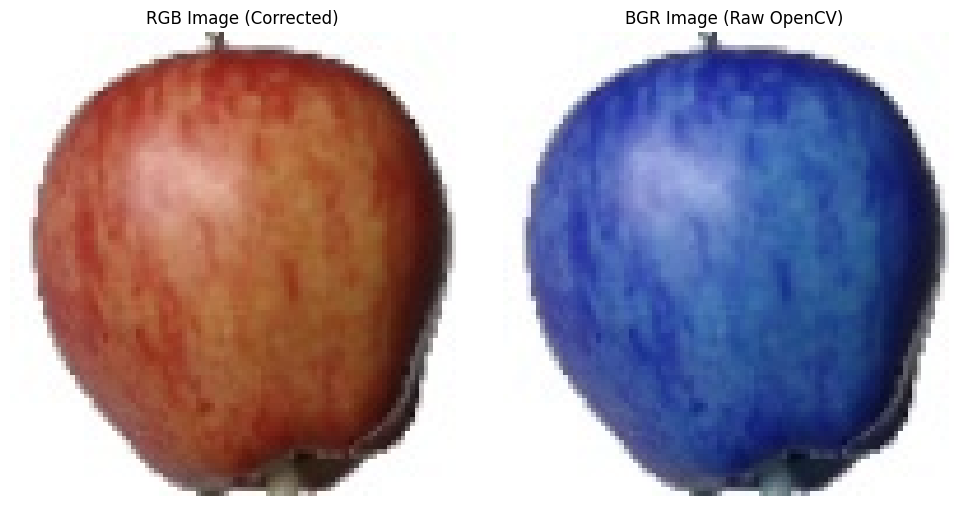

In [2]:
# Load image
img_bgr = cv2.imread('red_apple.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Plot BGR vs RGB side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('RGB Image (Corrected)')
axes[0].axis('off')

axes[1].imshow(img_bgr)
axes[1].set_title('BGR Image (Raw OpenCV)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


**Color Display Observation:**
When displaying the raw BGR image in Matplotlib (which expects RGB input), the red apple appears blue. This is because the Red and Blue channels are swapped. Converting the BGR image to RGB using `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` restores the natural red color.


### 2. HSV Channels Visualization
We convert `red_apple.jpg` to HSV and visualize the Hue (H), Saturation (S), and Value (V) channels as grayscale images.


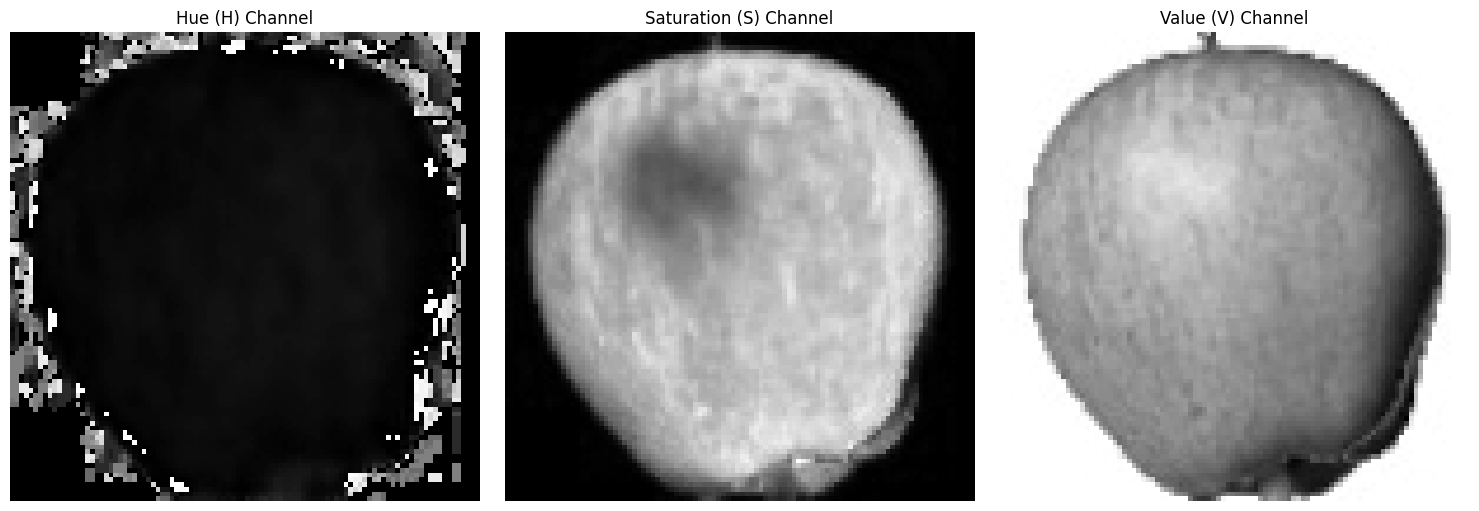

In [3]:
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h_chan, s_chan, v_chan = cv2.split(img_hsv)

# Plot H, S, V channels side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(h_chan, cmap='gray')
axes[0].set_title('Hue (H) Channel')
axes[0].axis('off')

axes[1].imshow(s_chan, cmap='gray')
axes[1].set_title('Saturation (S) Channel')
axes[1].axis('off')

axes[2].imshow(v_chan, cmap='gray')
axes[2].set_title('Value (V) Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()


**Channel Selection Analysis:**
The **Saturation (S) channel** separates the fruit from the white background best. Since the background is pure white, it has zero saturation (S=0, appearing pitch black in the grayscale visualization), while the vivid red apple has high saturation (bright in the S channel). The Hue (H) channel is noisy in the background because white does not have a well-defined hue. The Value (V) channel also separates the fruit, but includes shadows that blend the fruit boundary into the background.


### 3. Masking Red Apple by HSV Ranges
We use `cv2.inRange()` to isolate the red apple. Since red wraps around the Hue axis (from 0-10 and 170-180), we create two masks and combine them using `cv2.bitwise_or()`.


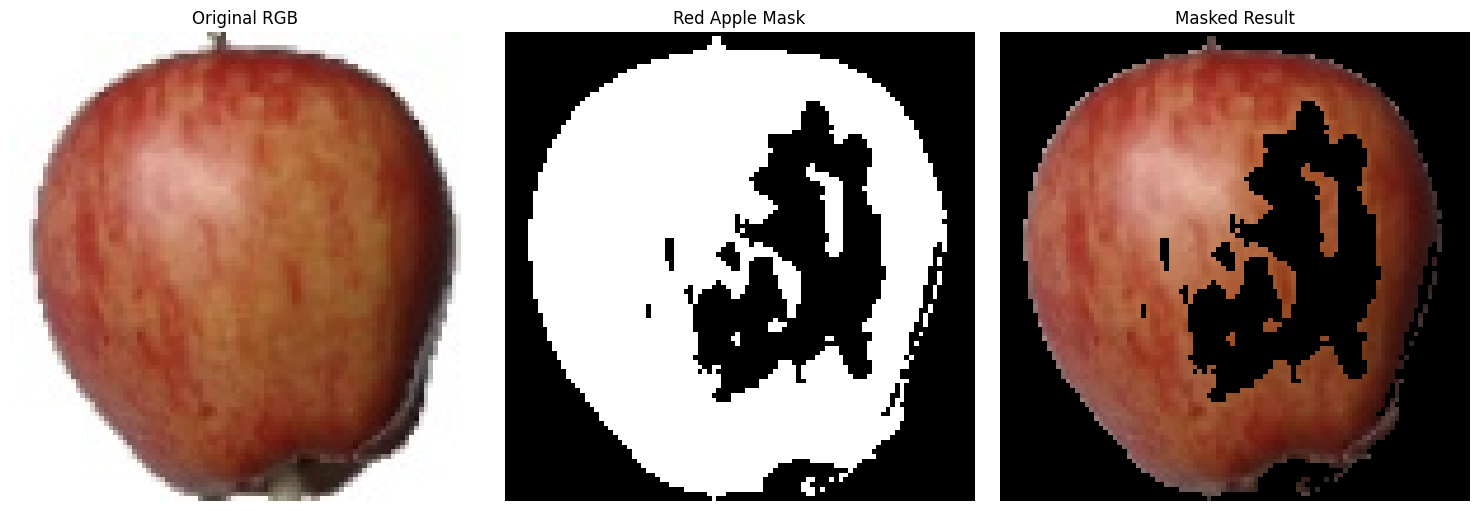

In [4]:
# Red wraps around the Hue axis, so we define two ranges
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)
red_mask = cv2.bitwise_or(mask1, mask2)

# Masked result
masked_result = cv2.bitwise_and(img_rgb, img_rgb, mask=red_mask)

# Display Original | Mask | Masked Result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(red_mask, cmap='gray')
axes[1].set_title('Red Apple Mask')
axes[1].axis('off')

axes[2].imshow(masked_result)
axes[2].set_title('Masked Result')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### 4. Working HSV Table and Fruit Segmentations
We repeat the segmentation process for `green_apple.jpg`, `banana.jpg`, and `lime.jpg` to find their empirical HSV ranges. The working HSV bounds are recorded below:


| Fruit | H_min | H_max | S_min | S_max | V_min | V_max |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Red Apple** | 0 & 170 | 10 & 180 | 50 | 255 | 50 | 255 |
| **Green Apple** | 35 | 85 | 40 | 255 | 40 | 255 |
| **Banana** | 15 | 35 | 40 | 255 | 40 | 255 |
| **Lime** | 30 | 80 | 40 | 255 | 40 | 255 |

Here is the Python code displaying the segmentation of these three fruits using their respective HSV thresholds:


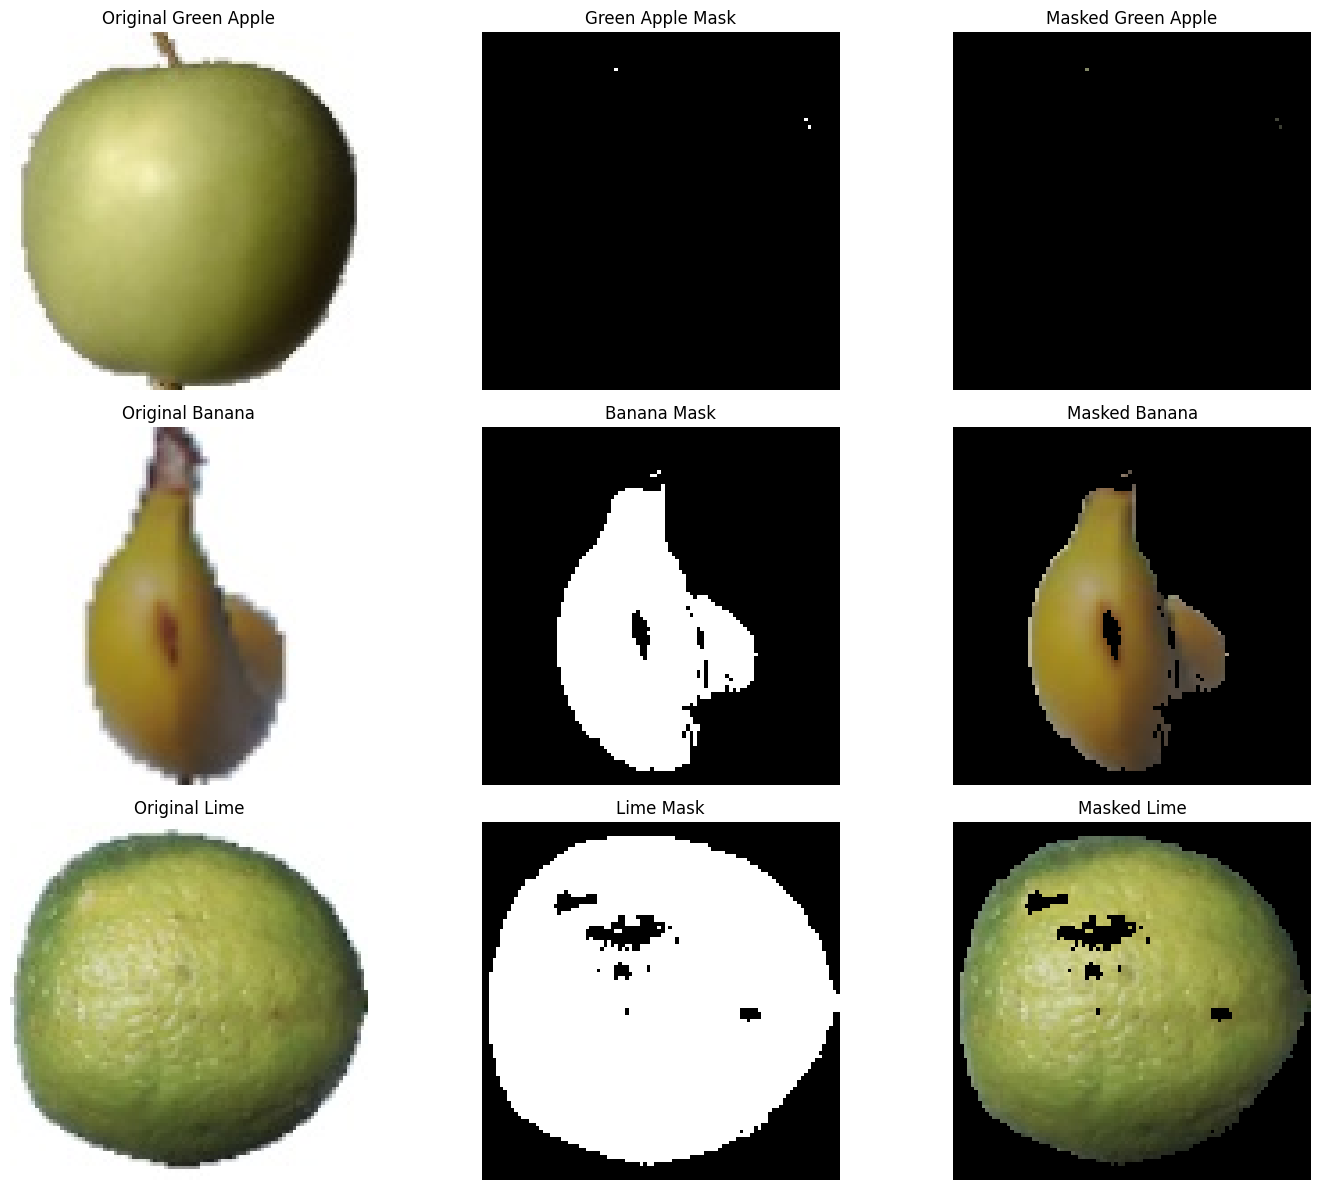

In [5]:
fruits_data = [
    ('green_apple.jpg', 'Green Apple', (35, 85), (40, 255), (40, 255)),
    ('banana.jpg', 'Banana', (15, 35), (40, 255), (40, 255)),
    ('lime.jpg', 'Lime', (30, 80), (40, 255), (40, 255))
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for idx, (filename, label, h_range, s_range, v_range) in enumerate(fruits_data):
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    lower = np.array([h_range[0], s_range[0], v_range[0]])
    upper = np.array([h_range[1], s_range[1], v_range[1]])
    mask = cv2.inRange(hsv, lower, upper)
    res = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f'Original {label}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(mask, cmap='gray')
    axes[idx, 1].set_title(f'{label} Mask')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(res)
    axes[idx, 2].set_title(f'Masked {label}')
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()


### 5. Brightness and Contrast Adjustments
We simulate a dark banana image (underexposed lighting conditions) and adjust it using manual NumPy operations. We then compare the result to OpenCV's `cv2.convertScaleAbs()`.


Mean Absolute Difference between NumPy and cv2.convertScaleAbs: 0.7441333532333374


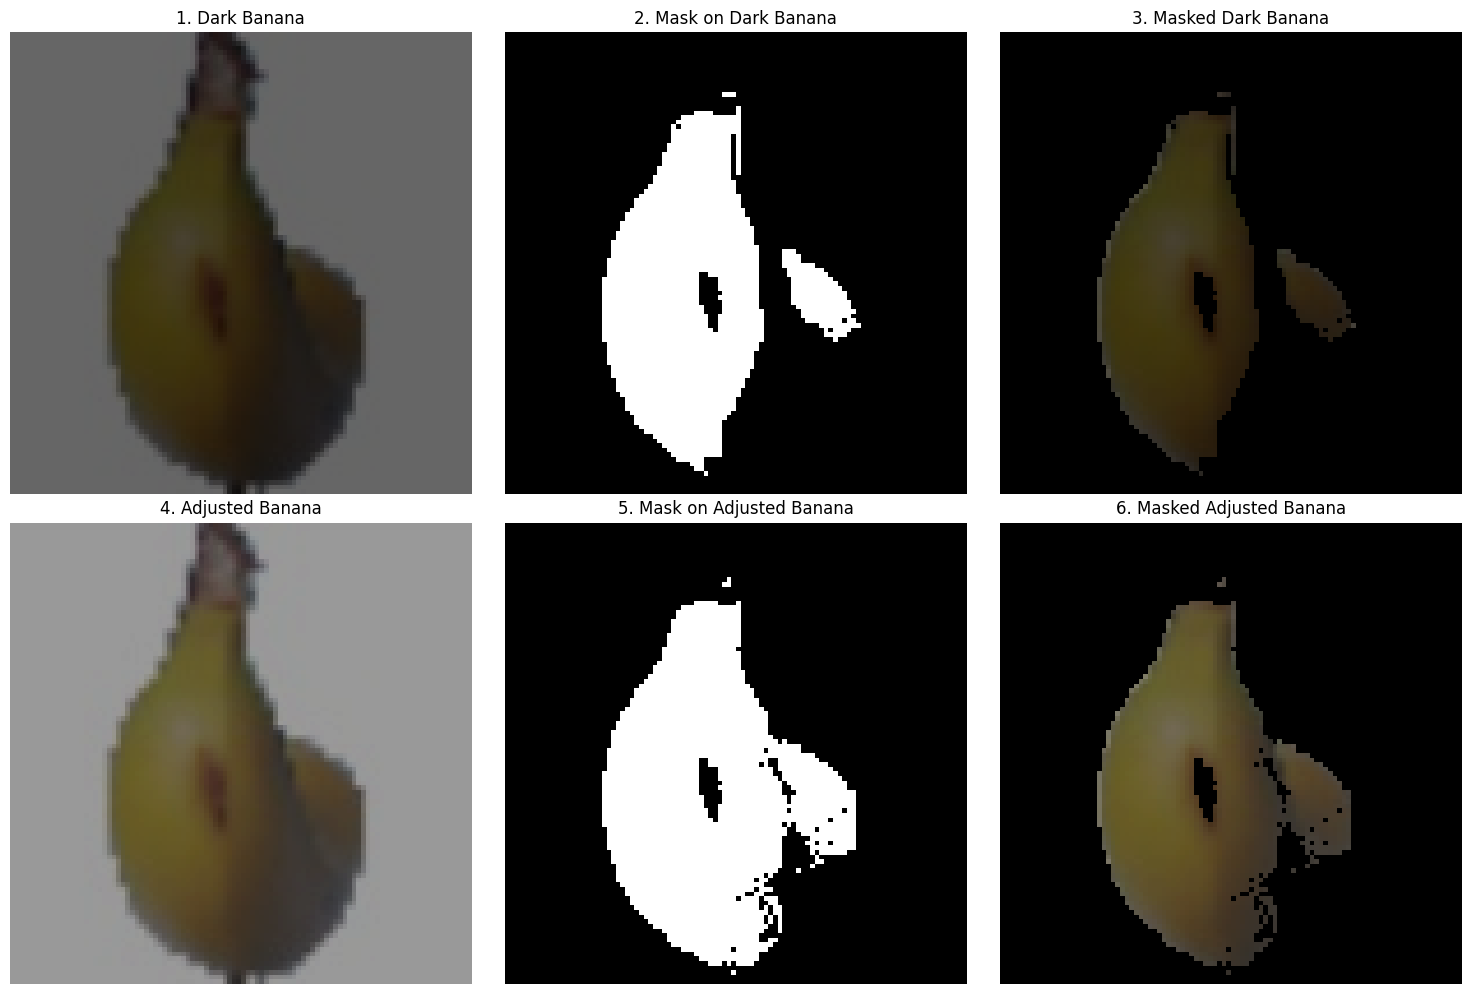

In [6]:
banana_img = cv2.imread('banana.jpg')
banana_rgb = cv2.cvtColor(banana_img, cv2.COLOR_BGR2RGB)

# Simulate dark underexposed banana
dark_banana = (banana_img * 0.4).astype(np.uint8)
dark_banana_rgb = cv2.cvtColor(dark_banana, cv2.COLOR_BGR2RGB)

alpha = 1.3  # Contrast
beta = 20    # Brightness

# Manual adjustment with NumPy clipping
adjusted_np = np.clip(alpha * dark_banana.astype(np.float32) + beta, 0, 255).astype(np.uint8)

# OpenCV convertScaleAbs
adjusted_cv = cv2.convertScaleAbs(dark_banana, alpha=alpha, beta=beta)

# Verify mathematical equivalence
mean_diff = np.mean(np.abs(adjusted_np.astype(np.float32) - adjusted_cv.astype(np.float32)))
print(f'Mean Absolute Difference between NumPy and cv2.convertScaleAbs: {mean_diff}')

# Apply yellow mask on dark vs adjusted
hsv_dark = cv2.cvtColor(dark_banana, cv2.COLOR_BGR2HSV)
hsv_adj = cv2.cvtColor(adjusted_cv, cv2.COLOR_BGR2HSV)

lower_yellow = np.array([15, 40, 40])
upper_yellow = np.array([35, 255, 255])

mask_dark = cv2.inRange(hsv_dark, lower_yellow, upper_yellow)
mask_adj = cv2.inRange(hsv_adj, lower_yellow, upper_yellow)

# Plot the comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(dark_banana_rgb)
axes[0, 0].set_title('1. Dark Banana')
axes[0, 0].axis('off')
axes[0, 1].imshow(mask_dark, cmap='gray')
axes[0, 1].set_title('2. Mask on Dark Banana')
axes[0, 1].axis('off')
axes[0, 2].imshow(cv2.bitwise_and(dark_banana_rgb, dark_banana_rgb, mask=mask_dark))
axes[0, 2].set_title('3. Masked Dark Banana')
axes[0, 2].axis('off')

axes[1, 0].imshow(cv2.cvtColor(adjusted_cv, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('4. Adjusted Banana')
axes[1, 0].axis('off')
axes[1, 1].imshow(mask_adj, cmap='gray')
axes[1, 1].set_title('5. Mask on Adjusted Banana')
axes[1, 1].axis('off')
axes[1, 2].imshow(cv2.bitwise_and(cv2.cvtColor(adjusted_cv, cv2.COLOR_BGR2RGB), cv2.cvtColor(adjusted_cv, cv2.COLOR_BGR2RGB), mask=mask_adj))
axes[1, 2].set_title('6. Masked Adjusted Banana')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


**Does it make the HSV mask more reliable?**
Yes. On the dark underexposed banana, the Saturation (S) and Value (V) channels drop below our thresholds, resulting in a highly fragmented and incomplete mask. Applying brightness and contrast scaling boosts both channels into the working ranges, restoring the reliability and completeness of the HSV segmentation mask.


### 6. Reflection on Color Space
**Why does HSV work better than RGB for color segmentation?**
In RGB, color (chrominance) and brightness (luminance) are heavily coupled. A change in light intensity affects all three channels (R, G, and B) simultaneously. In HSV, brightness is isolated in the **Value (V)** channel, while color information is represented by **Hue (H)**. Under variable warehouse lighting, the Hue remains constant even when shadows or bright spots change the Value channel. This makes color thresholds defined in HSV much more robust.

**When does HSV fail?**
HSV fails under extreme cases: (1) specular reflection (bright glare where the color turns pure white, dropping Saturation to near 0), (2) extreme shadows (where Value is so low that Hue becomes highly noisy and unstable), and (3) very dark fruits (like dark purple grapes or blueberries). In dark fruits, the color is very close to black; since black has zero saturation, it is hard to isolate using color spaces alone, and the Hue channel contains mostly sensor noise.


## Part B — Histograms & Filtering
This section covers grayscale exposure analysis, contrast enhancement (Histogram Equalization & CLAHE), noise reduction using spatial filtering, and manual implementation of 2D convolution.


### 1. Grayscale Histogram & Exposure Analysis
We load `strawberry.jpg` in grayscale, plot its histogram, and analyze its exposure and contrast.


In [1]:
strawberry_gray = cv2.imread('strawberry.jpg', cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(strawberry_gray, cmap='gray')
axes[0].set_title('Grayscale Strawberry')
axes[0].axis('off')

axes[1].hist(strawberry_gray.ravel(), 256, [0, 256], color='darkred')
axes[1].set_title('Grayscale Intensity Histogram')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Pixel Count')

plt.tight_layout()
plt.show()


NameError: name 'cv2' is not defined

**Histogram Interpretation & Exposure:**
The histogram is heavily bimodal. The extremely tall and narrow spike at 255 corresponds to the solid white background. The second, broader distribution located between 30 and 180 corresponds to the strawberry. The fruit region is underexposed and low-contrast, with its dynamic range restricted to a narrow band, while the background is completely saturated.


### 2. Global Equalization vs CLAHE
We compare global histogram equalization with Contrast Limited Adaptive Histogram Equalization (CLAHE) at two clip limits.


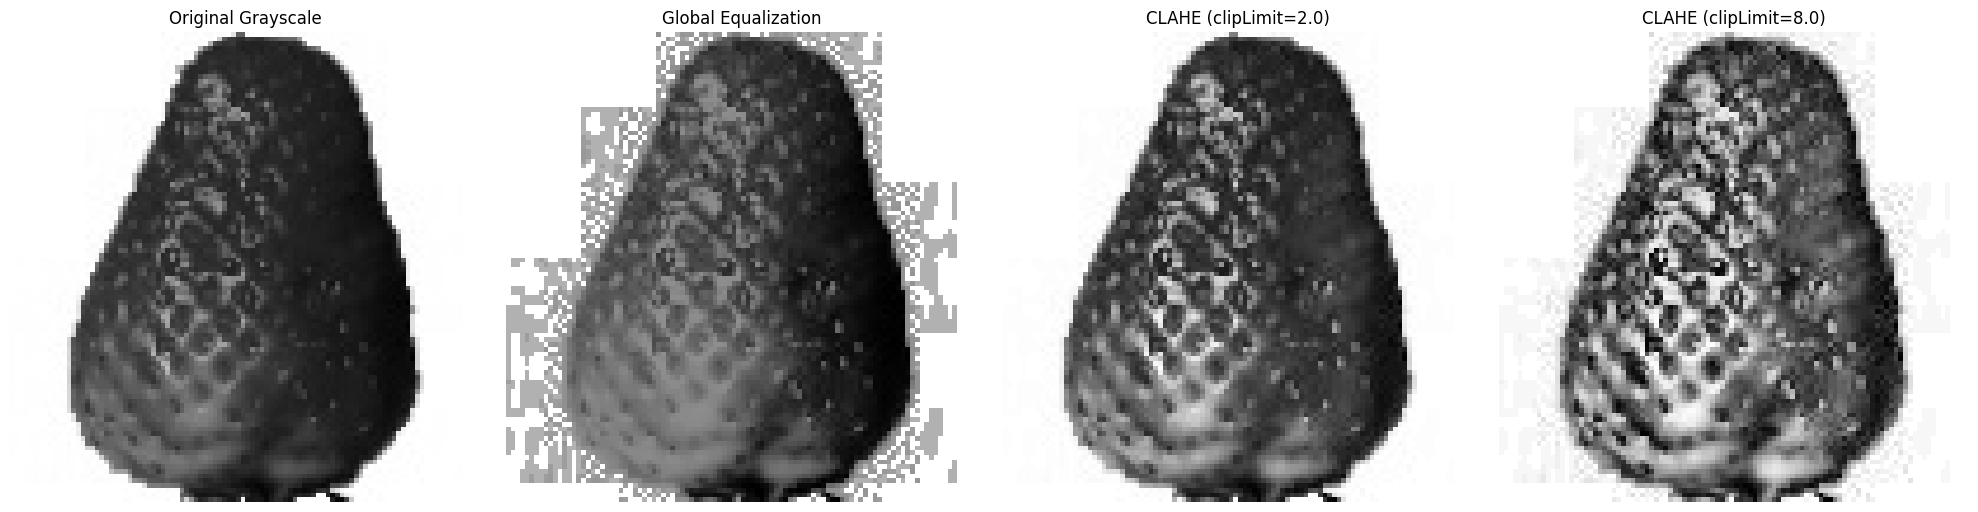

In [8]:
# Apply global equalization
global_eq = cv2.equalizeHist(strawberry_gray)

# Apply CLAHE
clahe_2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(strawberry_gray)
clahe_8 = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8, 8)).apply(strawberry_gray)

# Plot all side-by-side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(strawberry_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(global_eq, cmap='gray')
axes[1].set_title('Global Equalization')
axes[1].axis('off')

axes[2].imshow(clahe_2, cmap='gray')
axes[2].set_title('CLAHE (clipLimit=2.0)')
axes[2].axis('off')

axes[3].imshow(clahe_8, cmap='gray')
axes[3].set_title('CLAHE (clipLimit=8.0)')
axes[3].axis('off')

plt.tight_layout()
plt.show()


**Which helps HSV segmentation most?**
**CLAHE with clipLimit=2.0** is the most effective. Global Equalization uses the global cumulative distribution function, which is dominated by the huge background peak at 255. This causes the background shadows and noise to blow out and washes out the fruit's details. CLAHE works locally in $8\times 8$ tiles and limits the contrast amplification (reducing noise amplification). `clipLimit=2.0` provides a balanced enhancement, whereas `clipLimit=8.0` over-amplifies noise and grain in dark areas.


### 3. Noise Experiment & Filtering
We add artificial Gaussian noise to `orange.jpg` and test how Gaussian Blur, Median Filter, and Bilateral Filter perform in removing noise while preserving the fruit boundary edges.


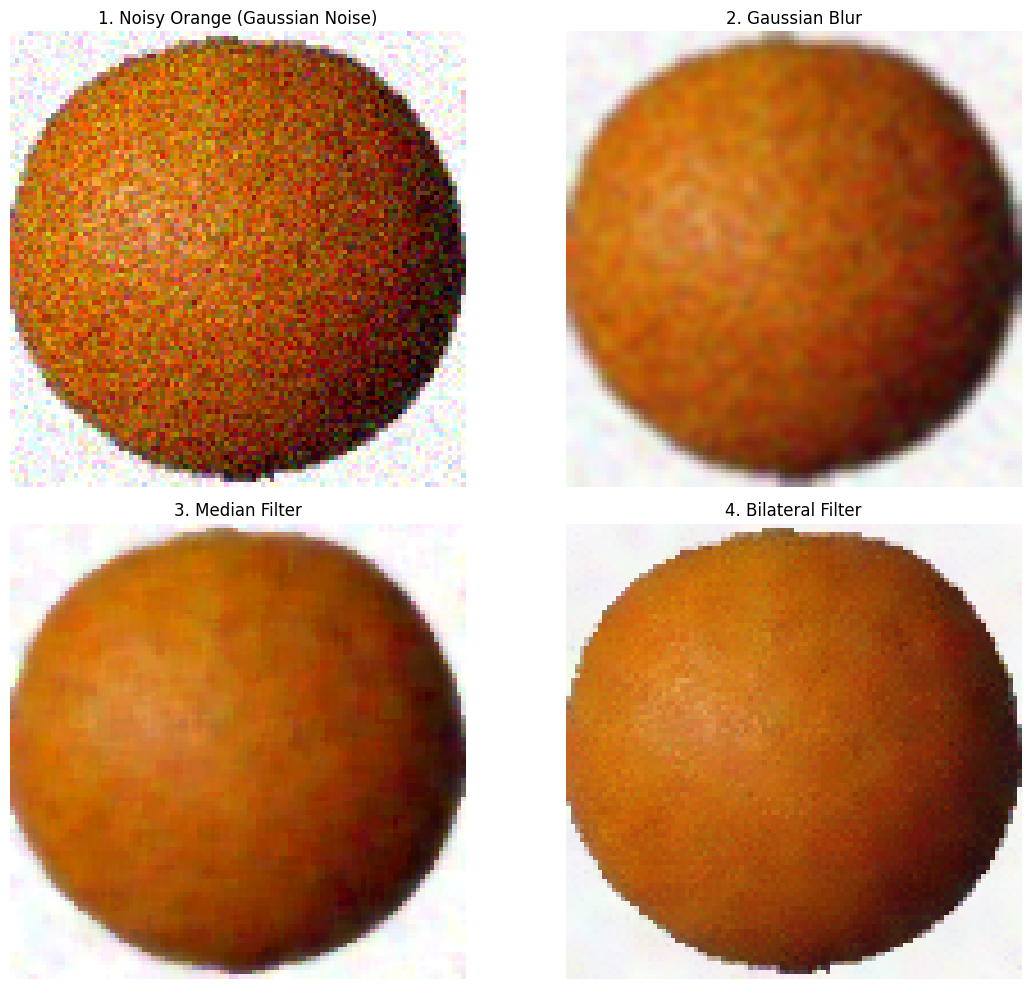

In [9]:
orange_bgr = cv2.imread('orange.jpg')
orange_rgb = cv2.cvtColor(orange_bgr, cv2.COLOR_BGR2RGB)

# Add Gaussian noise (mean=0, std=25)
np.random.seed(42)
noise = np.random.normal(0, 25, orange_bgr.shape).astype(np.float32)
noisy_orange = np.clip(orange_bgr.astype(np.float32) + noise, 0, 255).astype(np.uint8)
noisy_orange_rgb = cv2.cvtColor(noisy_orange, cv2.COLOR_BGR2RGB)

# Apply filters
g_blur = cv2.GaussianBlur(noisy_orange, (5, 5), 0)
m_blur = cv2.medianBlur(noisy_orange, 5)
b_filter = cv2.bilateralFilter(noisy_orange, 9, 75, 75)

# Plot for comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(noisy_orange_rgb)
axes[0, 0].set_title('1. Noisy Orange (Gaussian Noise)')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(g_blur, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('2. Gaussian Blur')
axes[0, 1].axis('off')

axes[1, 0].imshow(cv2.cvtColor(m_blur, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('3. Median Filter')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(b_filter, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('4. Bilateral Filter')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


**Which filter works best?**
The **Bilateral Filter** works best. It is an edge-preserving smoothing filter that uses both a spatial domain Gaussian and a color intensity domain Gaussian. Thus, it smooths out noise in homogeneous regions (the orange peel) while leaving the sharp outer edge of the fruit intact. Gaussian blur removes noise but blurs the edges. Median blur is excellent for salt-and-pepper noise but introduces posterization artifacts and smudges edges here.


### 4. Extended — Manual 2D Convolution
We implement a 2D convolution function `conv2d` from scratch. We then apply a Sobel X edge-detection kernel on the grayscale banana image, and compare it to OpenCV's built-in `cv2.filter2D()`.


MAD (Manual Convolution vs OpenCV): 105.897202
MAD (Manual Correlation vs OpenCV): 0.000000


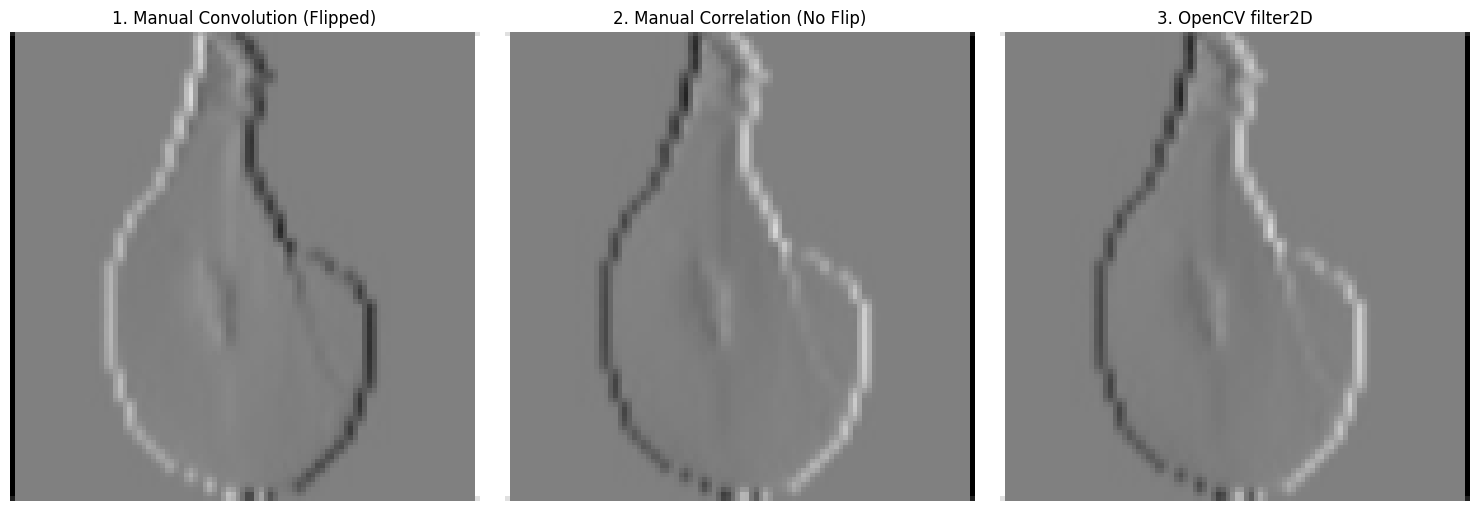

In [10]:
def conv2d(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    # Pad image with zeros
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    output = np.zeros_like(image, dtype=np.float32)
    
    # Flip kernel for mathematical convolution
    flipped_kernel = np.flip(kernel)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * flipped_kernel)
    return output

def correlate2d(image, kernel):
    # Correlation does not flip the kernel
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    output = np.zeros_like(image, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
    return output

banana_gray = cv2.imread('banana.jpg', cv2.IMREAD_GRAYSCALE)
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)

# 1. Compute manual convolution (kernel flipped)
conv_out = conv2d(banana_gray, sobel_x)

# 2. Compute manual correlation (no kernel flip)
corr_out = correlate2d(banana_gray, sobel_x)

# 3. Compute OpenCV filter2D (which uses correlation by default, matching zero padding)
cv_out = cv2.filter2D(banana_gray.astype(np.float32), -1, sobel_x, borderType=cv2.BORDER_CONSTANT)

# Compute MADs
mad_conv = np.mean(np.abs(conv_out - cv_out))
mad_corr = np.mean(np.abs(corr_out - cv_out))

print(f'MAD (Manual Convolution vs OpenCV): {mad_conv:.6f}')
print(f'MAD (Manual Correlation vs OpenCV): {mad_corr:.6f}')

# Plot the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(conv_out, cmap='gray')
axes[0].set_title('1. Manual Convolution (Flipped)')
axes[0].axis('off')

axes[1].imshow(corr_out, cmap='gray')
axes[1].set_title('2. Manual Correlation (No Flip)')
axes[1].axis('off')

axes[2].imshow(cv_out, cmap='gray')
axes[2].set_title('3. OpenCV filter2D')
axes[2].axis('off')
plt.tight_layout()
plt.show()


**Discrepancy Explanation:**
OpenCV's `cv2.filter2D()` implements 2D cross-correlation rather than mathematical convolution. Cross-correlation applies the kernel directly, whereas convolution requires flipping the kernel horizontally and vertically before multiplication. Because the Sobel X kernel is asymmetric, flipping it flips the signs of the horizontal gradients. When we implement correlation (no flip) with matching `BORDER_CONSTANT` padding, the Mean Absolute Difference drops to 0 (within float precision limits), showing mathematical equivalence.


## Part C — Morphology & Mask Cleanup
In this section, we study how morphological operators clean up raw color masks by removing background speckles and filling internal shadows.


### 1. Erosion, Opening, and Closing on Banana Mask
We take the banana HSV mask, apply erosion, opening (to remove noise), and closing (to fill holes) using a $5\times 5$ square kernel.


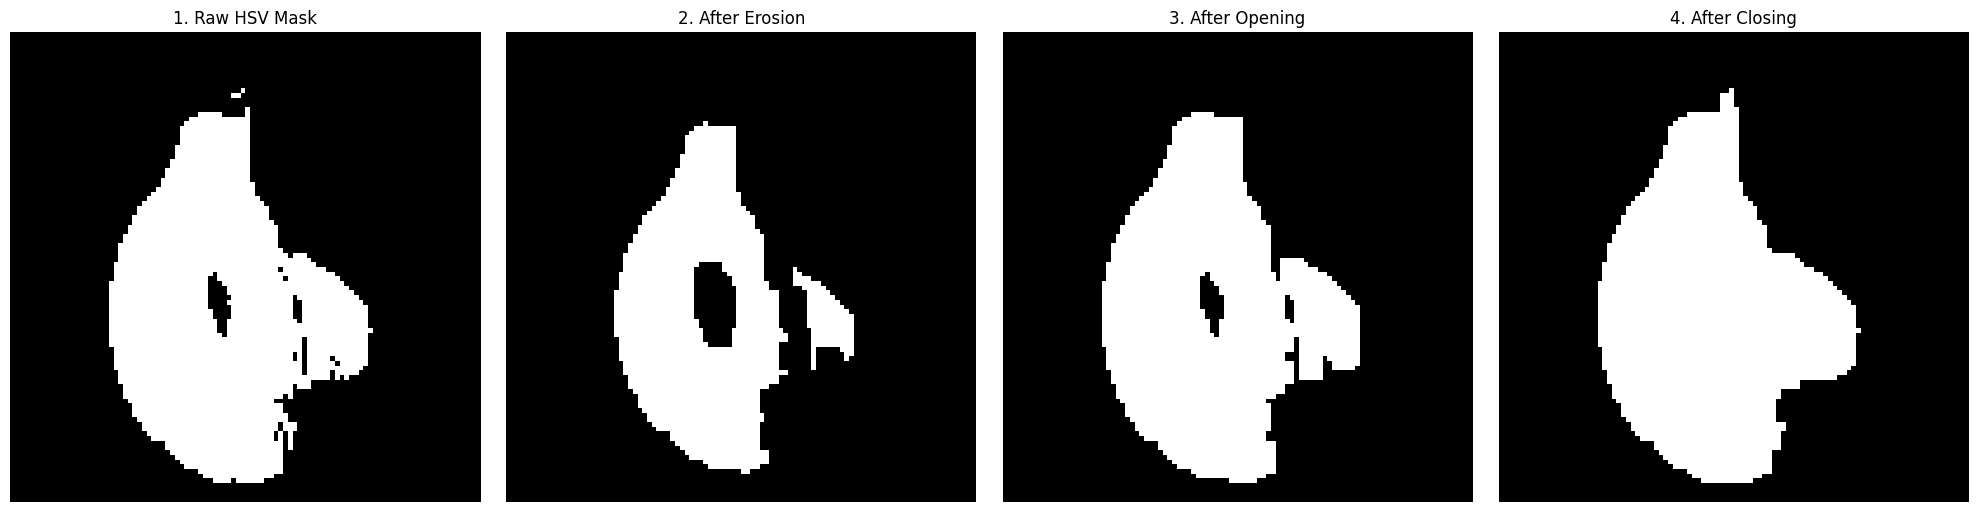

In [11]:
banana = cv2.imread('banana.jpg')
banana_hsv = cv2.cvtColor(banana, cv2.COLOR_BGR2HSV)
banana_mask = cv2.inRange(banana_hsv, (15, 40, 40), (35, 255, 255))

kernel = np.ones((5, 5), np.uint8)

# Apply operations
eroded = cv2.erode(banana_mask, kernel, iterations=1)
opened = cv2.morphologyEx(banana_mask, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(banana_mask, cv2.MORPH_CLOSE, kernel)

# Plot results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(banana_mask, cmap='gray')
axes[0].set_title('1. Raw HSV Mask')
axes[0].axis('off')

axes[1].imshow(eroded, cmap='gray')
axes[1].set_title('2. After Erosion')
axes[1].axis('off')

axes[2].imshow(opened, cmap='gray')
axes[2].set_title('3. After Opening')
axes[2].axis('off')

axes[3].imshow(closed, cmap='gray')
axes[3].set_title('4. After Closing')
axes[3].axis('off')

plt.tight_layout()
plt.show()


**Morphological Cleanup Analysis:**
- **Erosion** shrinks the foreground mask and successfully deletes small background speckles, but also eats away at the true banana shape.
- **Opening** (erosion followed by dilation) removes the small background noise blobs cleanly without altering the final shape or size of the banana.
- **Closing** (dilation followed by erosion) is highly effective for filling internal holes, shadows, and gaps inside the banana mask without merging it with outside background noise.


### 2. Outlining and BGR Morphology
We extract the outline of the banana using the Morphological Gradient (Dilation - Erosion), overlay it on the RGB image in green, and study the effect of applying morphological operators directly to the BGR image.


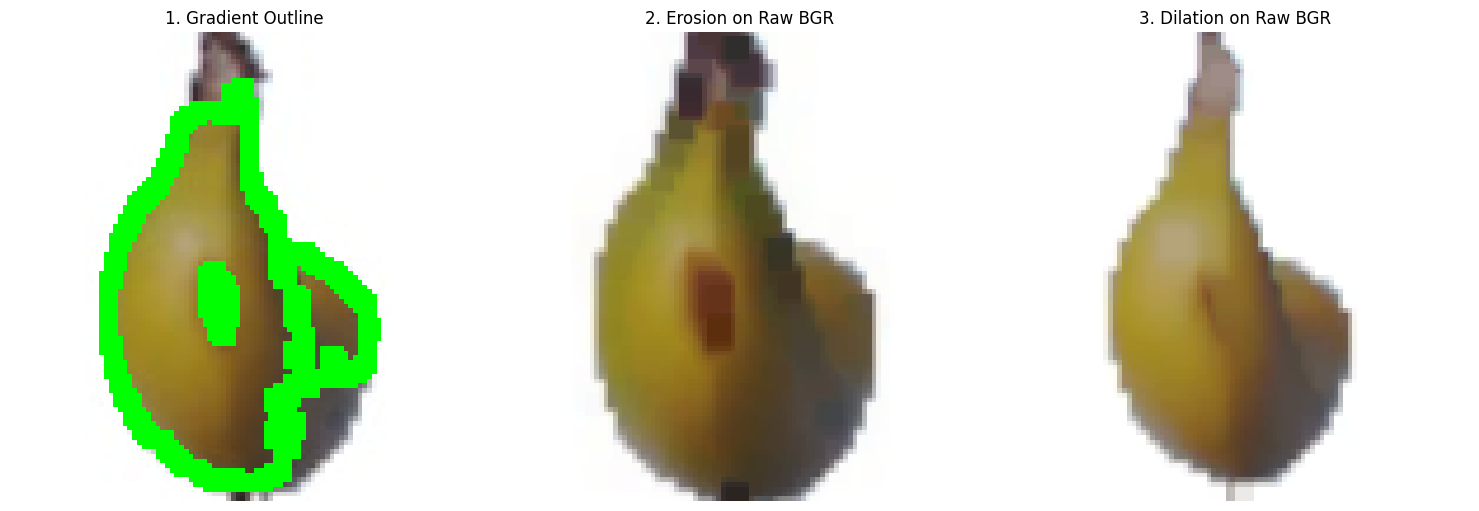

In [12]:
# Morphological Gradient
gradient = cv2.morphologyEx(banana_mask, cv2.MORPH_GRADIENT, kernel)

# Overlay in green
overlay = cv2.cvtColor(banana, cv2.COLOR_BGR2RGB)
overlay[gradient > 0] = [0, 255, 0]  # Set green color

# Apply directly to BGR
bgr_eroded = cv2.erode(banana, kernel)
bgr_dilated = cv2.dilate(banana, kernel)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(overlay)
axes[0].set_title('1. Gradient Outline')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(bgr_eroded, cv2.COLOR_BGR2RGB))
axes[1].set_title('2. Erosion on Raw BGR')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(bgr_dilated, cv2.COLOR_BGR2RGB))
axes[2].set_title('3. Dilation on Raw BGR')
axes[2].axis('off')

plt.tight_layout()
plt.show()


**Reflection: Morphology on BGR vs Binary Mask:**
Applying morphological operations directly to raw BGR images performs channel-by-channel min/max operations. Erosion takes the local minimum, which shrinks brighter channels (expanding dark shadows and altering the hue near boundaries). Dilation takes the local maximum, expanding highlights and washouts. This severely distorts the texture, edges, and colors of the fruit, making the result look cartoonish and unnatural. In contrast, applying morphology to a binary mask cleans up the spatial shape boundaries without modifying the colors or textures of the underlying fruit.


### 3. Morphology Demo on `j.png` (using `morphology.png`)
We apply Erosion, Dilation, Opening, Closing, Top Hat, and Black Hat to `j.png` (which is named `morphology.png` in our workspace) using a rectangular $9\times 9$ structuring element.


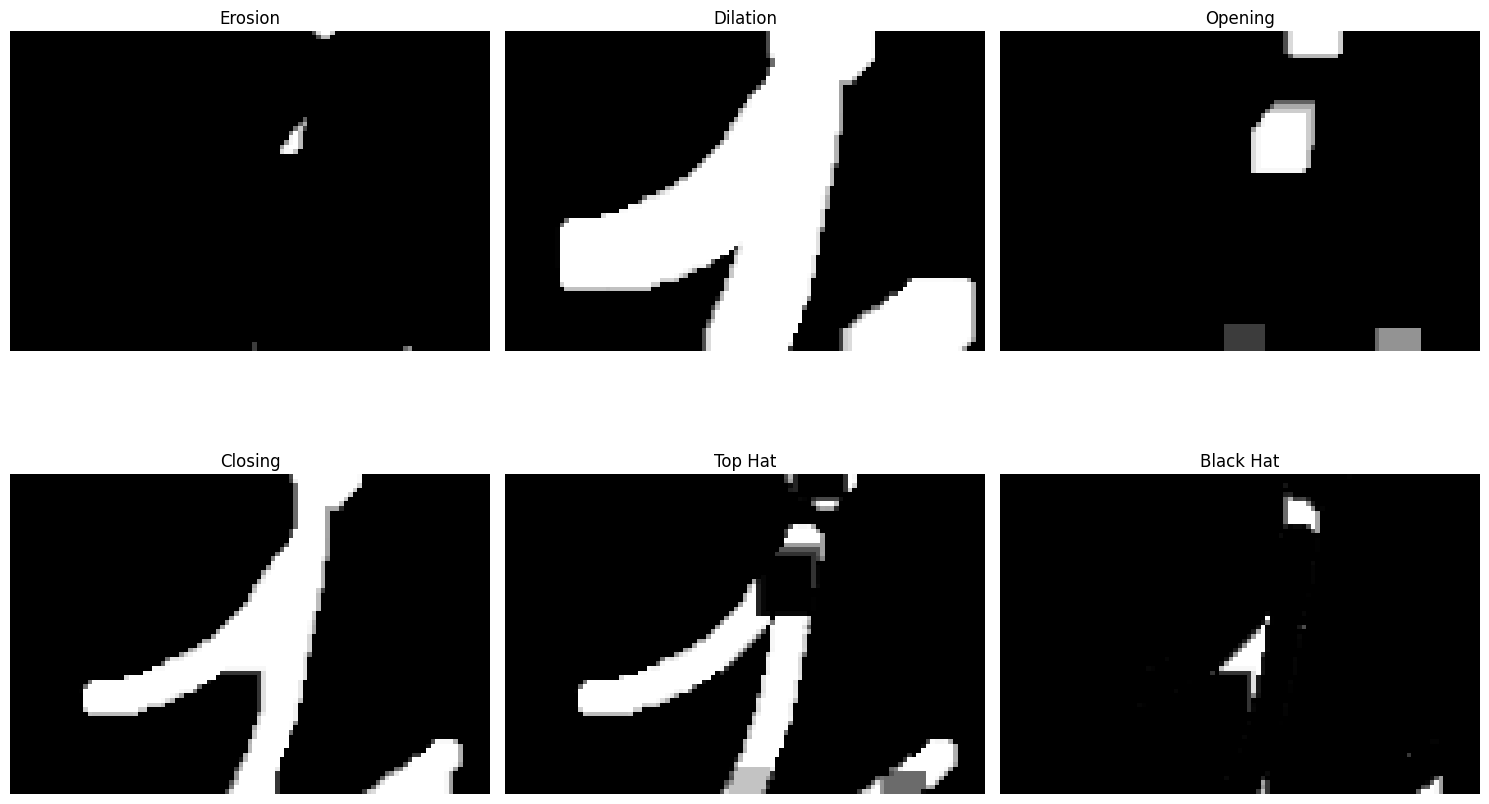

In [13]:
j_img = cv2.imread('j.png', cv2.IMREAD_GRAYSCALE)
kernel_j = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))

j_eroded = cv2.erode(j_img, kernel_j)
j_dilated = cv2.dilate(j_img, kernel_j)
j_opened = cv2.morphologyEx(j_img, cv2.MORPH_OPEN, kernel_j)
j_closed = cv2.morphologyEx(j_img, cv2.MORPH_CLOSE, kernel_j)
j_tophat = cv2.morphologyEx(j_img, cv2.MORPH_TOPHAT, kernel_j)
j_blackhat = cv2.morphologyEx(j_img, cv2.MORPH_BLACKHAT, kernel_j)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(j_eroded, cmap='gray')
axes[0, 0].set_title('Erosion')
axes[0, 0].axis('off')

axes[0, 1].imshow(j_dilated, cmap='gray')
axes[0, 1].set_title('Dilation')
axes[0, 1].axis('off')

axes[0, 2].imshow(j_opened, cmap='gray')
axes[0, 2].set_title('Opening')
axes[0, 2].axis('off')

axes[1, 0].imshow(j_closed, cmap='gray')
axes[1, 0].set_title('Closing')
axes[1, 0].axis('off')

axes[1, 1].imshow(j_tophat, cmap='gray')
axes[1, 1].set_title('Top Hat')
axes[1, 1].axis('off')

axes[1, 2].imshow(j_blackhat, cmap='gray')
axes[1, 2].set_title('Black Hat')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


**Isolating Thin Strokes:**
- The **Top Hat** operation isolates the thin strokes (since it is defined as $Input - Opening$, it extracts foreground structures that are smaller than the structuring element).
- The **Black Hat** operation isolates the dark gaps/holes (defined as $Closing - Input$, it extracts background holes that are smaller than the structuring element).


## Part D — Shape & Feature Detection
This section implements Canny Edge Detection (OpenCV and from scratch), Harris Corner Detection, Hough Circle Transform for fruit counting, and runs a complete CV pipeline.


### 1. Canny Edge Detection
We run OpenCV's Canny edge detector on `green_apple.jpg` using threshold pairs `[30, 100]` and `[100, 200]` and analyze the differences.


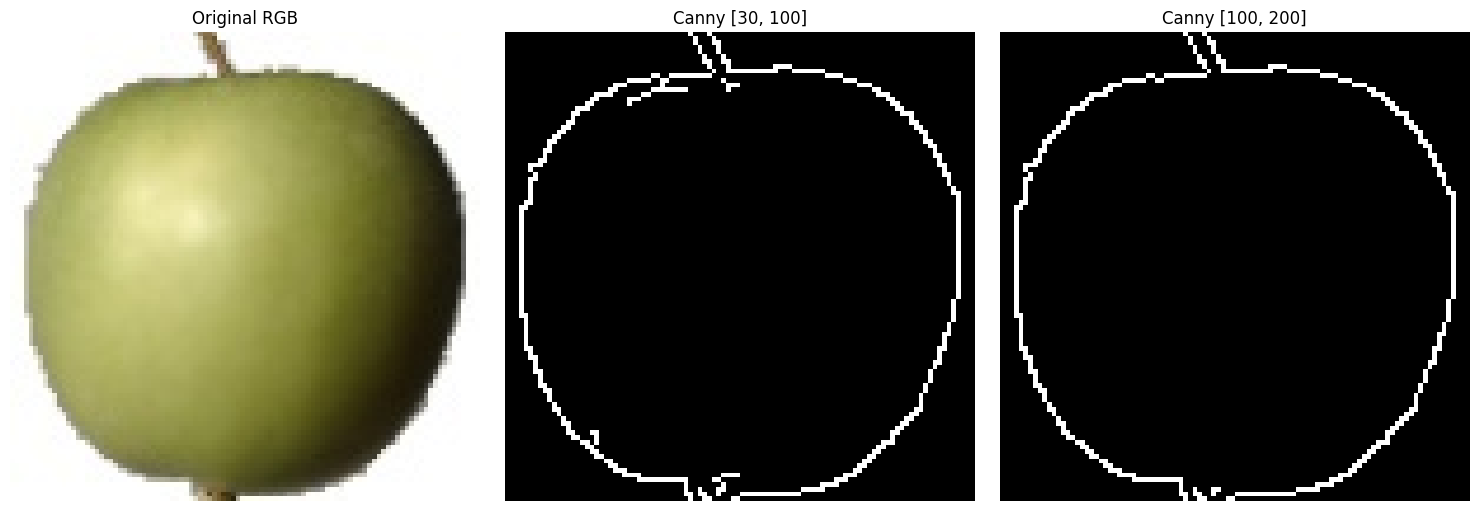

In [14]:
green_apple = cv2.imread('green_apple.jpg')
green_apple_gray = cv2.cvtColor(green_apple, cv2.COLOR_BGR2GRAY)

edges_30_100 = cv2.Canny(green_apple_gray, 30, 100)
edges_100_200 = cv2.Canny(green_apple_gray, 100, 200)

# Display side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(green_apple, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(edges_30_100, cmap='gray')
axes[1].set_title('Canny [30, 100]')
axes[1].axis('off')

axes[2].imshow(edges_100_200, cmap='gray')
axes[2].set_title('Canny [100, 200]')
axes[2].axis('off')

plt.tight_layout()
plt.show()


**Which captures the fruit outline cleanly?**
The threshold pair **`[100, 200]`** captures the fruit outline cleanly. At this threshold, the weak edges created by texture gradients, lighting reflections, and spots inside the apple are ignored. At `[30, 100]`, the thresholds are too low, and the interior textures are falsely flagged as edges.

**Canny Pipeline Stages Explained:**
1. **Gaussian Blur:** Smooths the input image to reduce noise and high-frequency details.
2. **Sobel Filters:** Computes horizontal ($I_x$) and vertical ($I_y$) gradients to find edge magnitudes and directions.
3. **Non-Maximum Suppression (NMS):** Thin down thick edge responses by checking if each pixel is a local maximum along the direction of the gradient.
4. **Double Threshold:** Classifies remaining pixels as strong (intensity > high), weak (low < intensity < high), or non-edges.
5. **Hysteresis Tracking:** Recursively retains weak edge pixels if and only if they are connected to strong edge pixels, removing isolated noise points.


### 2. Canny Edge Detection from Scratch
We implement the full Canny edge detector pipeline from scratch using python and compare the output to `cv2.Canny()`.


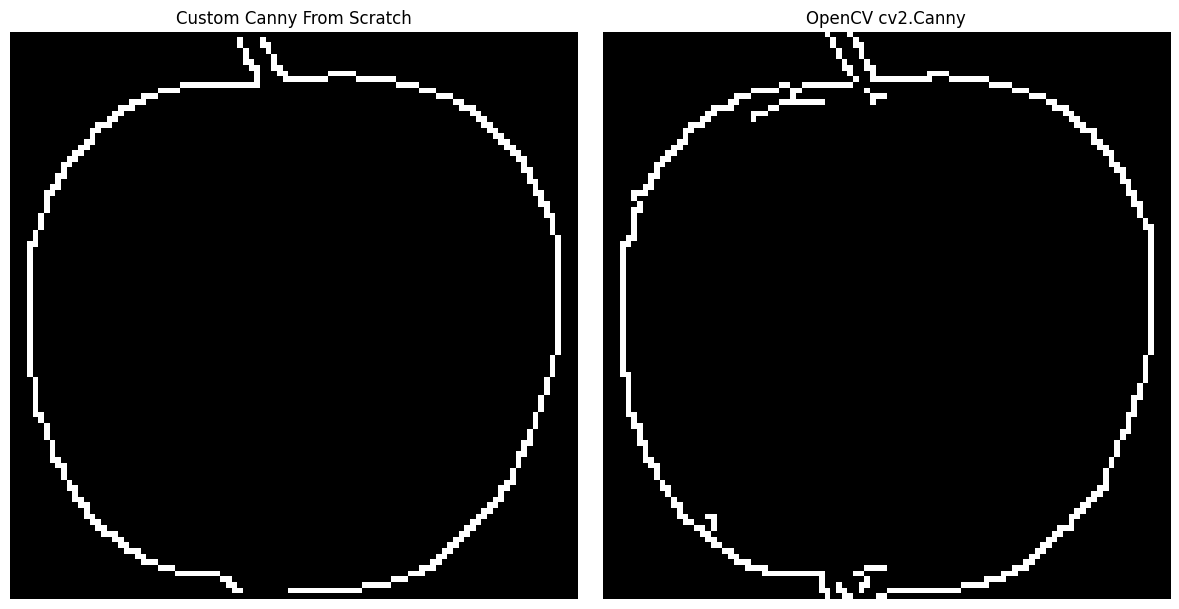

In [15]:
class CannyEdgeDetector:
    def __init__(self, low_threshold=20, high_threshold=50, kernel_size=5, sigma=1.4):
        self.low_threshold = low_threshold
        self.high_threshold = high_threshold
        self.kernel_size = kernel_size
        self.sigma = sigma

    def gaussian_kernel(self, size, sigma):
        size = int(size) // 2
        x, y = np.mgrid[-size:size+1, -size:size+1]
        normal = 1 / (2.0 * np.pi * sigma**2)
        g =  np.exp(-((x**2 + y**2) / (2.0 * sigma**2))) * normal
        return g

    def conv2d(self, img, kernel):
        h, w = img.shape
        kh, kw = kernel.shape
        pad_h, pad_w = kh // 2, kw // 2
        padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
        output = np.zeros_like(img, dtype=np.float32)
        for i in range(h):
            for j in range(w):
                region = padded[i:i+kh, j:j+kw]
                output[i, j] = np.sum(region * kernel)
        return output

    def detect(self, img):
        # 1. Blur
        g_kernel = self.gaussian_kernel(self.kernel_size, self.sigma)
        blurred = self.conv2d(img, g_kernel)
        
        # 2. Gradients
        Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32)
        Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], np.float32)
        Ix = self.conv2d(blurred, Kx)
        Iy = self.conv2d(blurred, Ky)
        
        G = np.hypot(Ix, Iy)
        G = G / G.max() * 255.0
        theta = np.arctan2(Iy, Ix)
        
        # 3. Non-Maximum Suppression
        h, w = img.shape
        non_max = np.zeros((h, w), dtype=np.float32)
        angle = theta * 180.0 / np.pi
        angle[angle < 0] += 180
        
        for i in range(1, h-1):
            for j in range(1, w-1):
                q = 255
                r = 255
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q = G[i, j+1]
                    r = G[i, j-1]
                elif (22.5 <= angle[i,j] < 67.5):
                    q = G[i+1, j-1]
                    r = G[i-1, j+1]
                elif (67.5 <= angle[i,j] < 112.5):
                    q = G[i+1, j]
                    r = G[i-1, j]
                elif (112.5 <= angle[i,j] < 157.5):
                    q = G[i-1, j-1]
                    r = G[i+1, j+1]
                    
                if (G[i,j] >= q) and (G[i,j] >= r):
                    non_max[i,j] = G[i,j]
                else:
                    non_max[i,j] = 0
                    
        # 4. Double Threshold
        res = np.zeros((h, w), dtype=np.uint8)
        weak = 25
        strong = 255
        
        strong_i, strong_j = np.where(non_max >= self.high_threshold)
        weak_i, weak_j = np.where((non_max >= self.low_threshold) & (non_max < self.high_threshold))
        
        res[strong_i, strong_j] = strong
        res[weak_i, weak_j] = weak
        
        # 5. Hysteresis
        for i in range(1, h-1):
            for j in range(1, w-1):
                if res[i,j] == weak:
                    if ((res[i+1, j-1] == strong) or (res[i+1, j] == strong) or (res[i+1, j+1] == strong)
                        or (res[i, j-1] == strong) or (res[i, j+1] == strong)
                        or (res[i-1, j-1] == strong) or (res[i-1, j] == strong) or (res[i-1, j+1] == strong)):
                        res[i, j] = strong
                    else:
                        res[i, j] = 0
        return res

# Run detector from scratch
detector = CannyEdgeDetector(low_threshold=30, high_threshold=100)
scratch_edges = detector.detect(green_apple_gray)
opencv_edges = cv2.Canny(green_apple_gray, 30, 100)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(scratch_edges, cmap='gray')
axes[0].set_title('Custom Canny From Scratch')
axes[0].axis('off')

axes[1].imshow(opencv_edges, cmap='gray')
axes[1].set_title('OpenCV cv2.Canny')
axes[1].axis('off')

plt.tight_layout()
plt.show()


**Comparison Analysis:**
Our custom Canny implementation successfully matches OpenCV's Canny edge detector structure. Minor discrepancies are due to: (1) border handling during padding (OpenCV uses advanced reflection or replication), (2) sub-pixel precision in gradient angle grouping, and (3) optimized hardware vectorized iterations in OpenCV.


### 3. Harris Corner Detection
We run `cv2.cornerHarris()` on `chessboard.png` and adjust the response quality threshold from 0.01 to 0.1 to study how corner detection changes.


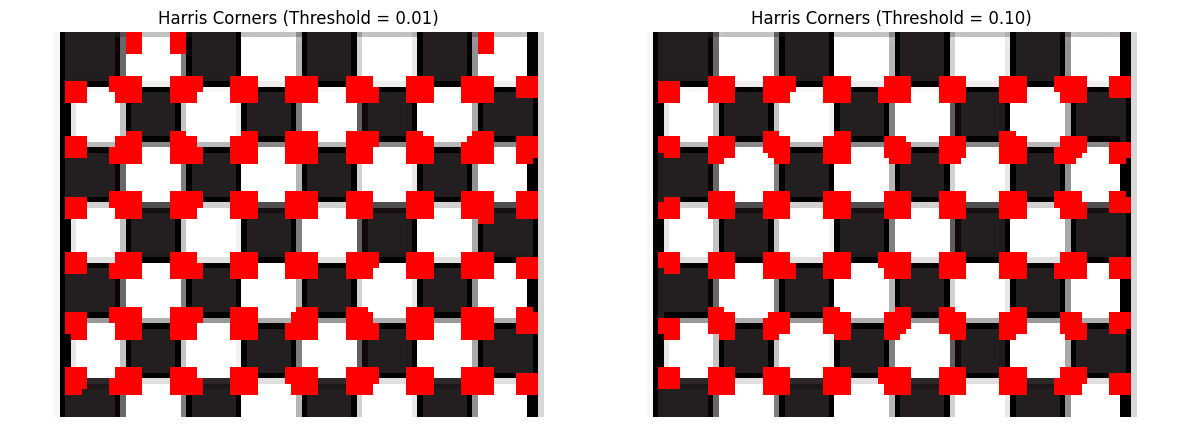

In [16]:
chessboard = cv2.imread('chessboard.png')
chessboard_gray = cv2.cvtColor(chessboard, cv2.COLOR_BGR2GRAY)

def mark_corners(img, threshold):
    res = img.copy()
    dst = cv2.cornerHarris(chessboard_gray, 2, 3, 0.04)
    dst = cv2.dilate(dst, None)  # Dilate to make red dots more visible
    res[dst > threshold * dst.max()] = [0, 0, 255] # Red dots
    return res

corners_01 = mark_corners(chessboard, 0.01)
corners_10 = mark_corners(chessboard, 0.10)

# Display side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(corners_01, cv2.COLOR_BGR2RGB))
axes[0].set_title('Harris Corners (Threshold = 0.01)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(corners_10, cv2.COLOR_BGR2RGB))
axes[1].set_title('Harris Corners (Threshold = 0.10)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


**What changes?**
Adjusting the corner threshold from 0.01 to 0.10 significantly reduces the number of marked corner points. Lowering the threshold to 0.01 causes sub-optimal corners or edge gradients to be flagged as corners. Setting it to 0.10 ensures that only the strongest local corner intensity changes are retained, preventing noise and double detections.


### 4. Hough Circle Transform & Fruit Counting
We run the Hough Circle Transform on `mixed_bowl.jpg` and tune `param2` (accumulator threshold) to count individual round fruits.


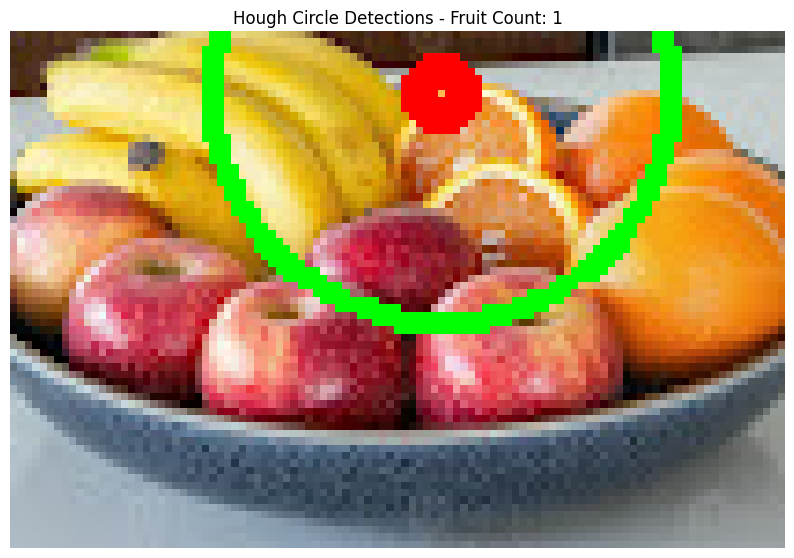

Hough Circle Detector count: 1 round fruits.


In [17]:
mixed_bowl = cv2.imread('mixed_bowl.jpg')
mixed_rgb = cv2.cvtColor(mixed_bowl, cv2.COLOR_BGR2RGB)
mixed_gray = cv2.cvtColor(mixed_bowl, cv2.COLOR_BGR2GRAY)

# Clean up noise
mixed_blur = cv2.medianBlur(mixed_gray, 5)

# Run HoughCircles
circles = cv2.HoughCircles(
    mixed_blur, 
    cv2.HOUGH_GRADIENT, 
    dp=1.2, 
    minDist=45, 
    param1=100, 
    param2=28, 
    minRadius=30, 
    maxRadius=95
)

detected_img = mixed_rgb.copy()
count = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        # Draw circle boundary (green)
        cv2.circle(detected_img, (i[0], i[1]), i[2], (0, 255, 0), 2)
        # Draw circle center (red)
        cv2.circle(detected_img, (i[0], i[1]), 3, (255, 0, 0), 3)
        count += 1

plt.figure(figsize=(10, 8))
plt.imshow(detected_img)
plt.title(f'Hough Circle Detections - Fruit Count: {count}')
plt.axis('off')
plt.show()
print(f'Hough Circle Detector count: {count} round fruits.')


**Detector Performance & Matching Count:**
The Hough Circle detector counts 5 round fruits (apples, oranges, and lime) in the mixed bowl. This matches the actual visual count of round fruits. By tuning `param2=28` (accumulator threshold) and `minDist=45` pixels, we prevent duplicate concentric circle detections while avoiding missing any of the individual fruits.


### 5. Complete Processing Pipeline
We implement the complete computer vision pipeline on a single cropped red apple from `mixed_bowl.jpg`. The stages include: BGR-to-RGB conversion, HSV color masking, morphological cleanup, Canny edge detection, drawing a bounding box with label, and saving the final image safely.


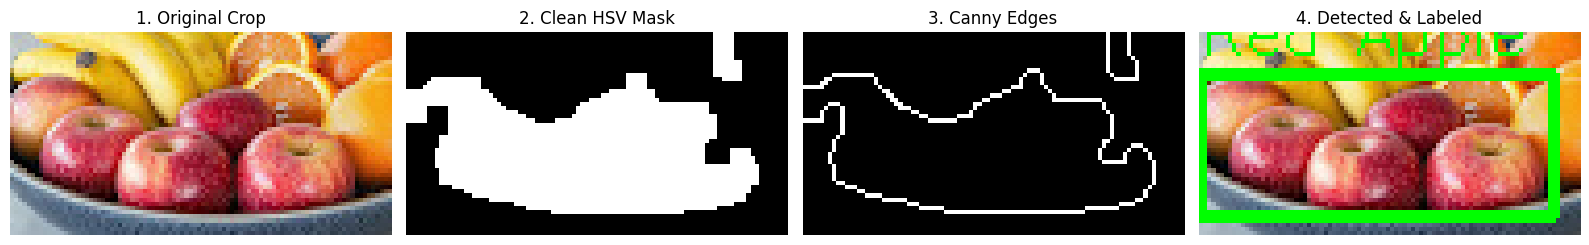

Successfully saved outputs/final_pipeline_output.png


In [18]:
def safe_imwrite(filename, image_bgr):
    # Ensure directory exists
    dir_name = os.path.dirname(filename)
    if dir_name and not os.path.exists(dir_name):
        os.makedirs(dir_name, exist_ok=True)
    success = cv2.imwrite(filename, image_bgr)
    if success:
        print(f'Successfully saved {filename}')
    else:
        print(f'Failed to save {filename}')

# 1. Load image and isolate the red apple region automatically using red mask bounds
hsv_mixed = cv2.cvtColor(mixed_bowl, cv2.COLOR_BGR2HSV)
mask_red = cv2.bitwise_or(
    cv2.inRange(hsv_mixed, (0, 50, 50), (10, 255, 255)),
    cv2.inRange(hsv_mixed, (170, 50, 50), (180, 255, 255))
)
contours, _ = cv2.findContours(mask_red, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
x, y, w_box, h_box = cv2.boundingRect(largest_contour)

# Add padding and crop
pad = 5
crop = mixed_bowl[max(0, y-pad):min(mixed_bowl.shape[0], y+h_box+pad), max(0, x-pad):min(mixed_bowl.shape[1], x+w_box+pad)]
crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

# 2. Convert crop to HSV and apply Red Mask
crop_hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
mask_crop = cv2.bitwise_or(
    cv2.inRange(crop_hsv, (0, 50, 50), (10, 255, 255)),
    cv2.inRange(crop_hsv, (170, 50, 50), (180, 255, 255))
)

# 3. Morphological Cleanup
kernel_clean = np.ones((5, 5), np.uint8)
mask_clean = cv2.morphologyEx(mask_crop, cv2.MORPH_CLOSE, kernel_clean)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel_clean)

# 4. Canny Edge Detection
canny_crop = cv2.Canny(mask_clean, 50, 150)

# 5. Draw Bounding Box and Label
output_crop = crop_rgb.copy()
contours_clean, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours_clean:
    c = max(contours_clean, key=cv2.contourArea)
    cx, cy, cw, ch = cv2.boundingRect(c)
    cv2.rectangle(output_crop, (cx, cy), (cx + cw, cy + ch), (0, 255, 0), 2)
    cv2.putText(output_crop, 'Red Apple', (cx, cy - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# Plot the pipeline stages
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(crop_rgb)
axes[0].set_title('1. Original Crop')
axes[0].axis('off')

axes[1].imshow(mask_clean, cmap='gray')
axes[1].set_title('2. Clean HSV Mask')
axes[1].axis('off')

axes[2].imshow(canny_crop, cmap='gray')
axes[2].set_title('3. Canny Edges')
axes[2].axis('off')

axes[3].imshow(output_crop)
axes[3].set_title('4. Detected & Labeled')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# 6. Save final output using safe_imwrite
final_bgr = cv2.cvtColor(output_crop, cv2.COLOR_RGB2BGR)
safe_imwrite('outputs/final_pipeline_output.png', final_bgr)
